# Boundary strength (insulation score) at boundaries
In cis: window size +-500Kb, ignore 2 diags.
In trans: window size +-500Kb, ignore 15 diags.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bioframe as bf

from pathlib import Path
from tqdm.auto import tqdm
import bbi
from tqdm.contrib.concurrent import process_map
from functools import partial
import colormaps as cmaps

In [2]:
plt.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42})
sns.set_context('talk')

## Load data

### Boundaries

In [3]:
boundaries = pd.read_parquet('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet')

In [4]:
boundaries = boundaries.query('chrom not in ["chrM", "chrY"]').reset_index(drop=True)

### Strength tracks

In [14]:
repo = Path('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/boundary_strength/')
strength_tracks = {sis: {cond: str(repo / f'{cond}_G2/bs.{cond}_G2.{sis}.bw')
                         for cond in ('WT', 'dCTCF')}
                   for sis in ('cis', 'trans')}

## Calculate genome-wide medians

In [15]:
def get_gw_median(track):
    chrom_vecs = list()
    for chrom in bbi.chromsizes(track):
        vec = bbi.fetch_intervals(track, chrom, 0, -1, iterator=False)['value']
        chrom_vecs.append(vec)
    total_vec = pd.concat(chrom_vecs, ignore_index=True)
    median = np.nanmedian(total_vec)
    return median

In [16]:
gw_medians = {sis: {cond: get_gw_median(track)
                    for cond, track in sis_data.items()}
              for sis, sis_data in strength_tracks.items()}

In [17]:
gw_medians

{'cis': {'WT': 2.1149607, 'dCTCF': 2.1297097},
 'trans': {'WT': 0.7875216, 'dCTCF': 0.76989174}}

## Precalculate strength at boundaries

In [18]:
def _extract_signal_chunk(df, path, bins=-1, summary='mean', missing=0):
    with bbi.open(path) as f:
        hmap = f.stackup(df['chrom'], df['start'], df['end'], bins=bins, summary=summary, missing=missing)
    return hmap


def extract_signal(df, path, bins=-1, summary='mean', missing=0, chunks=1, cores=1, silent=True):
    df_chuncks = np.array_split(df, chunks)
    func = partial(_extract_signal_chunk, path=path, bins=bins, summary=summary, missing=missing)
    results = process_map(func, df_chuncks, max_workers=cores, desc='chunk', disable=silent)
    return np.concatenate(results)

In [19]:
strength_cols = list()
for sis, sis_data in strength_tracks.items():
    for cond, track in sis_data.items():
        col = f"{sis}_{cond}"
        signal_vec = extract_signal(boundaries, track, bins=1, missing=np.nan, chunks=100, cores=8).squeeze()
        gw_median = gw_medians[sis][cond]
        boundaries[col] = signal_vec - gw_median
        strength_cols.append(col)

## Get stacklines

### Set parameters

In [20]:
FLANK = 500_000
RES = 10_000
BINS = 2 * FLANK // RES + 1

In [21]:
midpoints = (boundaries['start'] + boundaries['end']) // 2
windows = pd.DataFrame({'chrom': boundaries['chrom'],
                        'start': midpoints - FLANK,
                        'end': midpoints + FLANK})

In [22]:
strength_hmaps = dict()
for sis, sis_data in tqdm(strength_tracks.items()):
    strength_hmaps[sis] = dict()
    for cond, track in tqdm(sis_data.items(), desc=sis):
        signal_hmap = extract_signal(windows, track, bins=BINS, missing=np.nan, chunks=100, cores=8, silent=True)
        gw_median = gw_medians[sis][cond]
        signal_hmap = signal_hmap - gw_median
        signal_hmap[np.isinf(signal_hmap)] = np.nan
        strength_hmaps[sis][cond] = signal_hmap

  0%|          | 0/2 [00:00<?, ?it/s]

cis:   0%|          | 0/2 [00:00<?, ?it/s]

trans:   0%|          | 0/2 [00:00<?, ?it/s]

## Figure 3E - Average profiles

In [31]:
condition_palettes = {'WT': 'grey',
                      'dCTCF': 'black'
                     }

prof_ylims = {'cis': (-0.1, 0.95),
              'trans': (-0.05, 0.35)}

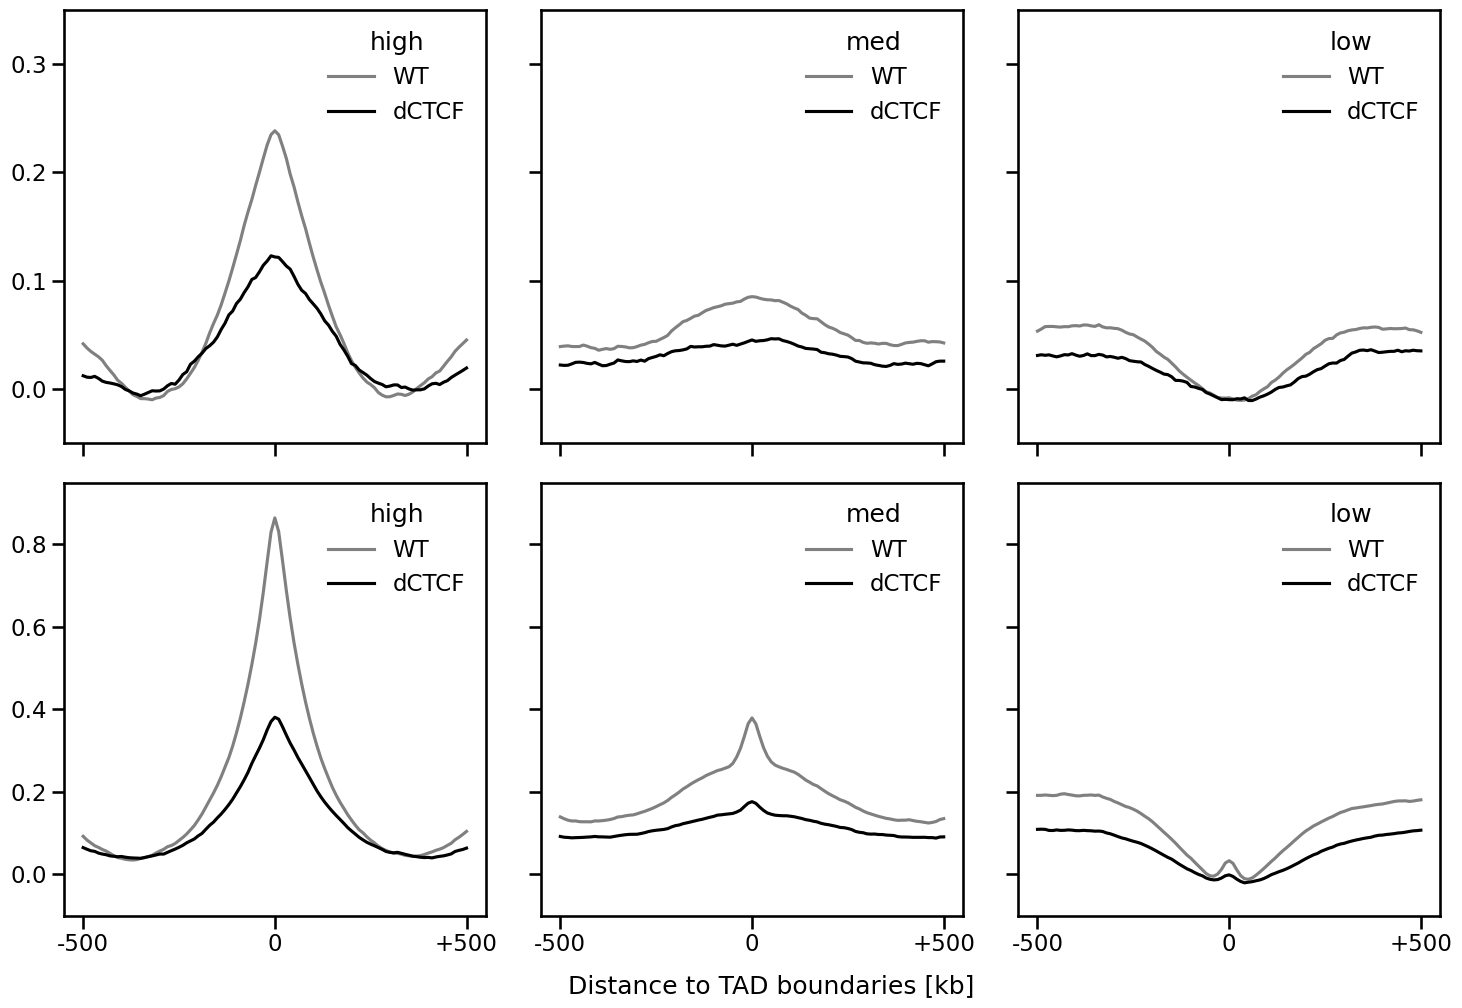

In [48]:
conditions = ('WT', 'dCTCF')
sis_list = ['trans', 'cis']

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey='row', sharex='col')

for row_idx, sis in enumerate(sis_list):
    sis_data = strength_hmaps[sis]
    for col_idx, (level, df) in enumerate(boundaries.groupby('levelGroup')):
        idx = df.index
        ax = axes[row_idx, col_idx]
        for cond in conditions:
            hmap = sis_data[cond]
            ax.plot(np.nanmean(hmap[idx, :], axis=0),
                label=cond,
                color=condition_palettes[cond],
                zorder=3)
        ax.legend(title=f'{level}', frameon=False)
        ax.set_ylim(*prof_ylims[sis])

for ax in axes[0, :]:
    ax.set_yticks([0, 0.1, 0.2, 0.3])

for ax in axes[1, :]:
    ax.set_xticks([0, 50, 100])
    ax.set_xticklabels(['-500', '0', '+500'])

fig.text(0.39, -0.01, 'Distance to TAD boundaries [kb]')
plt.tight_layout()
plt.show()